In [1]:
# Parameters
BATCH_MODE = "true"
SEED = 42
N_TRIES_PAR_TAILLE = 12

# App-22 : Coloration d'arêtes et conjecture de Tutte

**Navigation** : [<< App-21 VoiceLeading](App-21-VoiceLeading.ipynb) | [Index](../../README.md)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

1. **Définir** la coloration d'arêtes d'un graphe, son indice chromatique et les classes de Vizing
2. **Formuler** la 3-coloration d'arêtes d'un graphe cubique comme un CSP résolu par CP-SAT (chaque couleur = un couplage parfait)
3. **Construire** des familles témoins : le graphe de Petersen (plus petit snark), un graphe cubique à pont, les échelles de Möbius (non planaires mais apex)
4. **Vérifier empiriquement** un théorème récent (arXiv 2608.22870, 2026) : tout graphe cubique **apex** admet une 3-coloration d'arêtes

Ce notebook prolonge [App-2 : Coloration de Graphes](App-2-GraphColoring.ipynb), qui traitait la coloration de **sommets** — ici, ce sont les **arêtes** que l'on colore.

***

## 1. Introduction (~5 min)

### De la coloration de sommets à celle d'arêtes

Dans App-2, nous cherchions à colorier des **sommets** tels que deux sommets adjacents diffèrent. La **coloration d'arêtes** est le problème dual : colorier les **arêtes** d'un graphe telles que deux arêtes partageant un sommet reçoivent des couleurs distinctes. Le nombre minimal de couleurs est l'**indice chromatique** $\chi'(G)$.

Le théorème de **Vizing (1964)** encadre étroitement cet indice :

$$\Delta(G) \le \chi'(G) \le \Delta(G) + 1$$

où $\Delta(G)$ est le degré maximal. Les graphes atteignant la borne inférieure sont de **classe 1**, les autres de **classe 2**.

### Le cœur du problème : les graphes cubiques sans pont

Un graphe est **cubique** (ou 3-régulier) si tous ses sommets ont degré 3 ; il est **sans pont** si aucune arête n'est un pont (isthme). Pour un graphe cubique, $\chi'(G) \in \{3, 4\}$ : une 3-coloration d'arêtes d'un cubique revient à **partitionner ses arêtes en 3 couplages parfaits** — chaque couleur couvre chaque sommet exactement une fois.

La question « quel graphe cubique sans pont est de classe 1 ? » est structurellement difficile :

- **Conjecture de Tutte (1966)** : tout graphe cubique **planaire** sans pont est 3-arête-colorable — équivalente au théorème des quatre couleurs (résolue par conséquent en 1976).
- Un **snark** est un graphe cubique sans pont non 3-arête-colorable. Le plus petit est le **graphe de Petersen** (10 sommets).
- **Théorème (arXiv 2608.22870, 2026)** : tout graphe cubique **apex** — un graphe dont la suppression d'**un seul sommet** le rend planaire — est 3-arête-colorable. Ce résultat étend la conjecture de Tutte au-delà du planaire, avec une preuve assistée par ordinateur et un algorithme constructif en $O(n^2)$.

Dans ce notebook, nous **vérifions empiriquement** ce théorème avec CP-SAT : sur chaque instance testée, le solveur prouve la 3-colorabilité (ou son impossibilité — c'est un certificat, pas un espoir).

In [2]:
# Imports pour tout le notebook
import random
import time

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from ortools.sat.python import cp_model

# Reproductibilite
random.seed(SEED)

print("networkx", nx.__version__)
print("ortools CP-SAT pret")
print("SEED =", SEED)

networkx 3.6.1
ortools CP-SAT pret
SEED = 42


***

## 2. Définitions et familles témoins (~8 min)

Quatre propriétés structurelles vont orchestrer tout le notebook :

| Propriété | Définition | Vérification |
|---|---|---|
| **cubique** | tous les sommets ont degré 3 | parcours des degrés |
| **sans pont** | aucune arête dont la suppression déconnecte | `nx.bridges` |
| **planaire** | dessinable sans croisement | `nx.check_planarity` |
| **apex** | il existe un sommet $v$ tel que $G - v$ soit planaire | test de planarité après suppression, pour chaque $v$ |

Remarquez l'emboîtement : **planaire $\Rightarrow$ apex** (supprimer un sommet d'un graphe planaire laisse un graphe planaire). L'intérêt du théorème de 2026 est précisément la zone **apex mais non planaire**, invisible pour Tutte-1966.

Nous assemblons nos familles témoins : $K_4$ et le prisme triangulaire (planiares triviaux), le graphe de Petersen (le snark minimal), et un graphe cubique **avec pont** construit à la main pour la section 4.

In [3]:
# Definitions structurelles
def is_cubic(G: nx.Graph) -> bool:
    return all(deg == 3 for _, deg in G.degree())


def is_bridgeless(G: nx.Graph) -> bool:
    return len(list(nx.bridges(G))) == 0


def is_planar(G: nx.Graph) -> bool:
    return nx.check_planarity(G)[0]


def is_apex(G: nx.Graph) -> bool:
    for v in G.nodes():
        H = G.copy()
        H.remove_node(v)
        if nx.check_planarity(H)[0]:
            return True
    return False


def describe(name: str, G: nx.Graph) -> dict:
    return {
        "graphe": name,
        "n": G.number_of_nodes(),
        "m": G.number_of_edges(),
        "cubique": is_cubic(G),
        "sans_pont": is_bridgeless(G),
        "planaire": is_planar(G),
        "apex": is_apex(G),
    }


def cubic_with_bridge() -> nx.Graph:
    """Deux copies de K4 moins une arete, recollees par un sommet de chaque
    cote, relies par un unique pont. Cubique, avec exactement un pont."""
    G = nx.Graph()
    for tag in ("a", "b"):
        for i in range(4):
            for j in range(i + 1, 4):
                if {i, j} != {2, 3}:  # on retire l'arete (2,3) de chaque K4
                    G.add_edge((tag, i), (tag, j))
    G.add_edge("wa", ("a", 2))
    G.add_edge("wa", ("a", 3))
    G.add_edge("wb", ("b", 2))
    G.add_edge("wb", ("b", 3))
    G.add_edge("wa", "wb")  # le pont
    return G


TEMOINS = {
    "K4": nx.complete_graph(4),
    "prisme triangulaire": nx.circular_ladder_graph(3),
    "Petersen": nx.petersen_graph(),
    "cubique a pont": cubic_with_bridge(),
}

df_temoins = pd.DataFrame([describe(nom, G) for nom, G in TEMOINS.items()])
df_temoins

,graphe,n,m,cubique,sans_pont,planaire,apex
0,K4,4,6,True,True,True,True
1,prisme triangulaire,6,9,True,True,True,True
2,Petersen,10,15,True,True,False,False
3,cubique a pont,10,15,True,False,True,True


### Interprétation : lecture du tableau

Le tableau confirme l'orthogonalité des propriétés :

- **K4** et le **prisme** : planaires et donc apex — la 3-coloration est garantie par Tutte-1966 (via le théorème des quatre couleurs).
- **Petersen** : cubique, sans pont, mais **non planaire et non apex**. Il ne *peut pas* être apex si le théorème de 2026 est vrai — sinon il serait 3-colorable, ce qu'il n'est pas (section 3). L'expérience confirmera ce que la logique impose.
- Le **cubique à pont** : planaire, mais son pont va précisément lui interdire toute 3-coloration (section 4) — l'hypothèse « sans pont » n'est pas décorative.

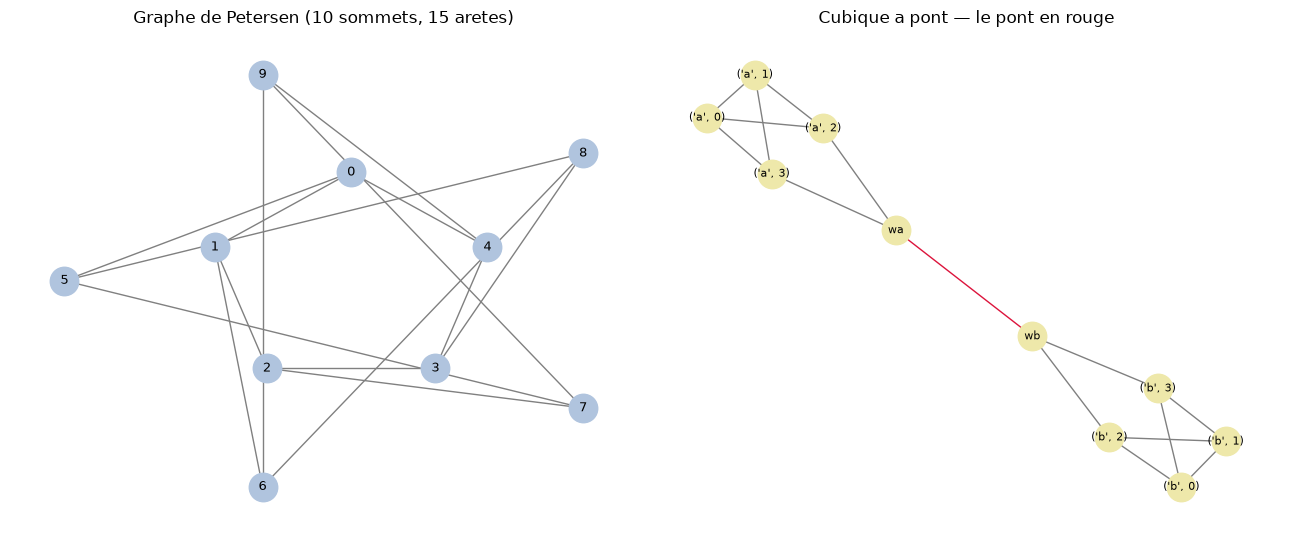

In [4]:
# Visualisation : Petersen et le graphe a pont
PETERSEN = TEMOINS["Petersen"]
G_PONT = TEMOINS["cubique a pont"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

pos_p = nx.shell_layout(PETERSEN, nlist=[range(5), range(5, 10)])
nx.draw(PETERSEN, pos_p, ax=axes[0], node_color="lightsteelblue", edge_color="gray",
        node_size=420, with_labels=True, font_size=9)
axes[0].set_title("Graphe de Petersen (10 sommets, 15 aretes)")

pos_b = nx.spring_layout(G_PONT, seed=SEED)
ponts = list(nx.bridges(G_PONT))
edge_colors = ["crimson" if e in ponts or (e[1], e[0]) in ponts else "gray"
               for e in G_PONT.edges()]
nx.draw(G_PONT, pos_b, ax=axes[1], node_color="palegoldenrod", edge_color=edge_colors,
        node_size=420, with_labels=True, font_size=8)
axes[1].set_title("Cubique a pont — le pont en rouge")
plt.tight_layout()
plt.show()

### Interprétation visuelle

À gauche, le Petersen : sa symétrie pentagonale le rend non planaire (il contient une subdivision de $K_{3,3}$). À droite, les deux copies de $K_4$ amputées d'une arête sont recollées par l'arête rouge — le **pont** : le seul chemin entre les deux moitiés. Nous verrons en section 4 pourquoi cette seule arête rend la 3-coloration impossible, quand bien même le graphe est planaire.

***

## 3. Formulation CP-SAT de la k-coloration d'arêtes (~8 min)

La traduction en CSP est directe et c'est là toute sa force :

- **Variables** : $x_{e,c} \in \{0, 1\}$ pour chaque arête $e$ et couleur $c \in \{0, \dots, k-1\}$ — « l'arête $e$ reçoit-elle la couleur $c$ ? »
- **Contrainte 1** (une couleur par arête) : pour chaque arête $e$, $\sum_c x_{e,c} = 1$
- **Contrainte 2** (pas de conflit au sommet) : pour chaque sommet $v$ et chaque couleur $c$, **au plus une** arête incidente à $v$ porte la couleur $c$

Pour un graphe cubique avec $k = 3$, la contrainte 2 devient « exactement une » par principe des tiroirs (3 arêtes incidentes, 3 couleurs distinctes) : chaque couleur forme alors un **couplage parfait** — $n$ sommets, $n/2$ arêtes par couleur, $3n/2$ arêtes au total, la partition exacte recherchée. Avec $k = 4$ (borne de Vizing), une couleur peut manquer en chaque sommet.

Si le modèle est **INFEASIBLE**, CP-SAT a *prouvé* qu'aucune 3-coloration n'existe pour ce graphe : c'est un certificat d'exhaustivité, pas un échec de recherche.

In [5]:
# Modele CP-SAT de la k-coloration d'aretes
def edge_coloring_cpsat(G: nx.Graph, k: int = 3, time_limit: float = 10.0):
    """Renvoie un dict {arete: couleur} si une k-coloration d'aretes existe,
    None sinon (INFEASIBLE = certificat d'impossibilite)."""
    edges = list(G.edges())
    incidence = {v: [] for v in G.nodes()}
    for idx, (u, v) in enumerate(edges):
        incidence[u].append(idx)
        incidence[v].append(idx)

    model = cp_model.CpModel()
    x = {(i, c): model.NewBoolVar(f"x_{i}_{c}")
         for i in range(len(edges)) for c in range(k)}
    for i in range(len(edges)):
        model.AddExactlyOne([x[(i, c)] for c in range(k)])
    for v, edge_ids in incidence.items():
        for c in range(k):
            # Au plus une arete de couleur c incidente a v. Pour k = degre,
            # le principe des tiroirs force exactement une (couplage parfait) ;
            # pour k = degre + 1 (borne de Vizing), une couleur peut manquer.
            model.AddAtMostOne([x[(i, c)] for i in edge_ids])

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    status = solver.Solve(model)
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {edges[i]: c for i in range(len(edges))
                for c in range(k) if solver.Value(x[(i, c)])}
    return None


# Verification sur les temoins, k = 3
verdicts = {}
for nom, G in TEMOINS.items():
    t0 = time.perf_counter()
    coloring = edge_coloring_cpsat(G, k=3)
    dt_ms = (time.perf_counter() - t0) * 1000
    verdicts[nom] = (coloring is not None, dt_ms)
    etat = "3-colorable" if coloring is not None else "INFEASIBLE (chi' >= 4)"
    print(f"{nom:22s} -> {etat:28s} ({dt_ms:.1f} ms)")

# Et la 4-coloration de Petersen (borne de Vizing atteinte) ?
t0 = time.perf_counter()
col4 = edge_coloring_cpsat(PETERSEN, k=4)
print(f"Petersen en 4 couleurs -> {'trouve' if col4 else 'INFEASIBLE'}"
      f" ({(time.perf_counter() - t0) * 1000:.1f} ms)")

K4                     -> 3-colorable                  (120.8 ms)
prisme triangulaire    -> 3-colorable                  (10.2 ms)
Petersen               -> INFEASIBLE (chi' >= 4)       (3.0 ms)
cubique a pont         -> INFEASIBLE (chi' >= 4)       (2.5 ms)
Petersen en 4 couleurs -> trouve (30.5 ms)


### Interprétation : le solveur discrimine

Le verdict est net, et c'est un contraste **structurel** (pas une différence de vitesse) :

- **K4, prisme** : 3-colorables, comme l'exige Tutte-1966 pour les planaires sans pont.
- **Petersen** : `INFEASIBLE` en $k=3$ — CP-SAT a **épuisé l'espace de recherche** et prouvé qu'aucune partition en 3 couplages parfaits n'existe. Avec $k=4$, une coloration est trouvée : $\chi'(\text{Petersen}) = 4 = \Delta + 1$, il est de **classe 2** — c'est la définition d'un snark.
- Le **cubique à pont** : `INFEASIBLE` en $k=3$ alors qu'il est planaire — première alerte que l'hypothèse « sans pont » est indispensable (section 4).

Notons la différence de nature entre les deux sorties : SAT donne un **témoin** (la coloration), UNSAT donne un **certificat** (aucune n'existe). Le même instrument prouve les deux.

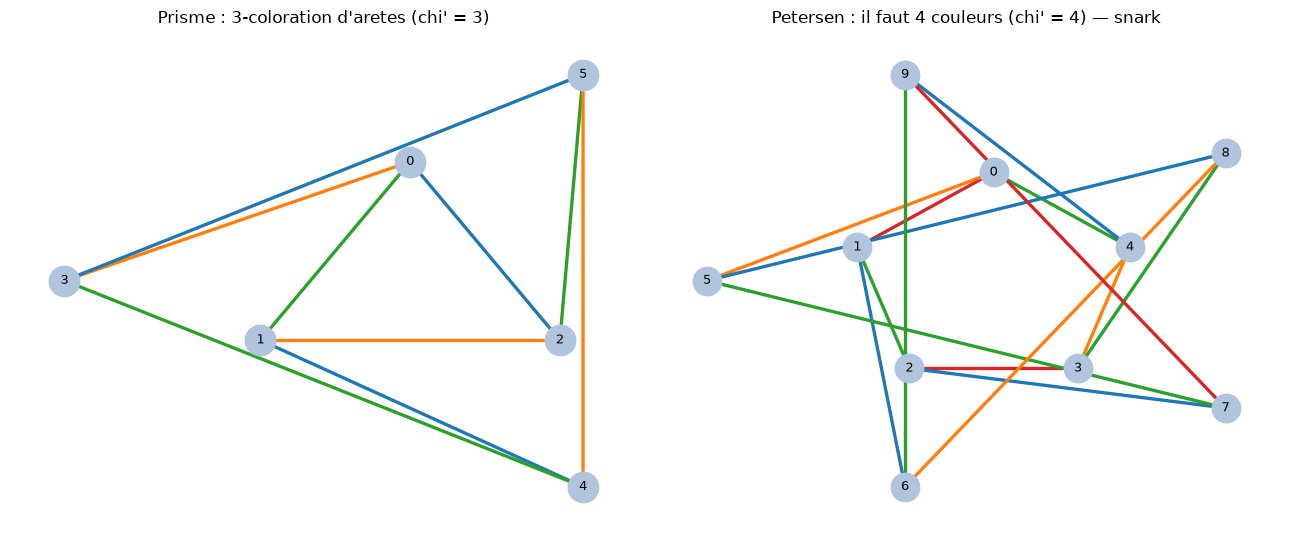

prisme, couleur 0 : 3 aretes couvrant [0, 1, 2, 3, 4, 5]
prisme, couleur 1 : 3 aretes couvrant [0, 1, 2, 3, 4, 5]
prisme, couleur 2 : 3 aretes couvrant [0, 1, 2, 3, 4, 5]


In [6]:
# Visualisation des colorations trouvees
PALETTE = ["tab:blue", "tab:green", "tab:orange", "tab:red"]


def couleurs_aretes(G, coloring):
    return [PALETTE[coloring[e]] if e in coloring else PALETTE[coloring[(e[1], e[0])]]
            for e in G.edges()]


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

prisme = TEMOINS["prisme triangulaire"]
col_p = edge_coloring_cpsat(prisme, k=3)
nx.draw(prisme, nx.shell_layout(prisme, nlist=[range(3), range(3, 6)]), ax=axes[0],
        node_color="lightsteelblue", node_size=480, with_labels=True, font_size=9,
        edge_color=couleurs_aretes(prisme, col_p), width=2.4)
axes[0].set_title("Prisme : 3-coloration d'aretes (chi' = 3)")

nx.draw(PETERSEN, pos_p, ax=axes[1], node_color="lightsteelblue", node_size=420,
        with_labels=True, font_size=9, edge_color=couleurs_aretes(PETERSEN, col4),
        width=2.4)
axes[1].set_title("Petersen : il faut 4 couleurs (chi' = 4) — snark")
plt.tight_layout()
plt.show()

# Chaque couleur du prisme forme-t-elle bien un couplage parfait ?
for c in range(3):
    aretes_c = [e for e, col in col_p.items() if col == c]
    sommets_c = sorted({u for e in aretes_c for u in e})
    print(f"prisme, couleur {c} : {len(aretes_c)} aretes couvrant {sommets_c}")

### Interprétation : chaque couleur est un couplage parfait

Sur le prisme, le décompte par couleur confirme la structure : chaque couleur couvre les **6 sommets** en **3 arêtes** disjointes — un couplage parfait. Les trois couleurs partitionnent les 9 arêtes : $3 \times 3 = 9$. Sur Petersen, la 4ᵉ couleur est inévitable ; aucune des 4 classes n'est alors un couplage parfait du graphe entier.

***

## 4. Pourquoi « sans pont » est nécessaire (~5 min)

L'argument est un classique de parité. Supposons une 3-coloration d'arêtes d'un graphe cubique $G$ contenant un pont $e = xy$, et notons $A$ la composante de $G - e$ contenant $x$. Alors :

1. Chaque couleur forme un **couplage parfait** de $G$ (contrainte 2 ci-dessus) — elle couvre $A$ entièrement par des arêtes **internes** à $A$ (la seule arête sortante est le pont, qui a une couleur unique).
2. Un couplage interne couvre les sommets de $A$ par paires : $|A|$ doit être **pair**.
3. Mais en sommant les degrés dans $A$ : $3|A| = 2|E_A| + 1$ (le pont compte pour 1), donc $|A|$ est **impair**.

Contradiction : **aucun graphe cubique avec un pont n'est 3-arête-colorable**. Le pont est un obstacle catégoriel, pas un accident. C'est pourquoi toutes les conjectures de cette famille (Tutte 1966, le théorème apex de 2026) portent sur les graphes **sans pont**.

In [7]:
# Verifications sur le graphe a pont
print("ponts :", list(nx.bridges(G_PONT)))

# Decomposition par rapport au pont wa-wb : les composantes de G - pont
H = G_PONT.copy()
H.remove_edge("wa", "wb")
for i, comp in enumerate(nx.connected_components(H)):
    sous = G_PONT.subgraph(comp)
    print(f"composante {i} : |A| = {len(comp)} sommets (parite : "
          f"{'pair' if len(comp) % 2 == 0 else 'IMPAIR'}), "
          f"3|A| = {3 * len(comp)}, 2|E_A| + 1 = {2 * sous.number_of_edges() + 1}")

col3 = edge_coloring_cpsat(G_PONT, k=3)
print("3-coloration du graphe a pont :", "trouvee" if col3 else "INFEASIBLE")

ponts : [('wa', 'wb')]
composante 0 : |A| = 5 sommets (parite : IMPAIR), 3|A| = 15, 2|E_A| + 1 = 15
composante 1 : |A| = 5 sommets (parite : IMPAIR), 3|A| = 15, 2|E_A| + 1 = 15
3-coloration du graphe a pont : INFEASIBLE


### Interprétation : la parité à l'œuvre

Les composantes de $G - \text{pont}$ ont un nombre de sommets **impair**, et la relation $3|A| = 2|E_A| + 1$ se lit directement dans la sortie : c'est exactement le point 3 de l'argument. CP-SAT confirme : `INFEASIBLE` en $k=3$ — le solveur et l'argument de parité racontent la même histoire, l'un par énumération exhaustive, l'autre en trois lignes. La preuve mathématique est plus satisfaisante ; le solveur la **vérifie** et généralise le contrôle à n'importe quel graphe.

***

## 5. Graphes apex non planaires : le théorème de 2026 à l'épreuve (~10 min)

Tutte-1966 couvre le planaire ; le théorème de arXiv 2608.22870 (2026) étend la 3-coloration aux cubiques sans pont **apex** — y compris celles qui sont **non planaires**, zone où aucune conjecture antérieure n'osait s'aventurer.

Une famille naturelle habite cette zone : les **échelles de Möbius** $M_n$. On les construit en ajoutant à un cycle de $n$ sommets les « barreaux » reliant chaque sommet à son opposé ($i \leftrightarrow i + n/2$). Pour $n \ge 8$ elles sont non planaires ; nous vérifions qu'elles restent **apex** (supprimer un sommet bien choisi dénoue le ruban) et **3-colorables**.

Puis nous lançons l'échantillonnage : des cubiques aléatoires sans pont de tailles croissantes, chacune classée (planaire / apex / autre) et soumise à CP-SAT. **Prédiction du théorème : aucune instance apex ne doit ressortir INFEASIBLE.**

In [8]:
# Echelles de Mobius : non planaires, apex, 3-colorables
def mobius_ladder(n: int) -> nx.Graph:
    """Echelle de Mobius M_n : cycle de n sommets + barreaux i -- (i + n/2)."""
    G = nx.cycle_graph(n)
    for i in range(n // 2):
        G.add_edge(i, (i + n // 2) % n)
    return G


MOBIUS = {f"M{n}": mobius_ladder(n) for n in (8, 10, 12)}
for nom, G in MOBIUS.items():
    t0 = time.perf_counter()
    ok = edge_coloring_cpsat(G, k=3) is not None
    dt = (time.perf_counter() - t0) * 1000
    print(f"{nom:5s} 3-colorable = {ok} ({dt:.1f} ms)")

pd.DataFrame([describe(nom, G) for nom, G in MOBIUS.items()])

M8    3-colorable = True (36.6 ms)
M10   3-colorable = True (27.6 ms)


M12   3-colorable = True (16.0 ms)


,graphe,n,m,cubique,sans_pont,planaire,apex
0,M8,8,12,True,True,False,True
1,M10,10,15,True,True,False,True
2,M12,12,18,True,True,False,True


### Interprétation : la zone apex-non-planaire existe et est habitable

Le tableau des échelles de Möbius montre la configuration clé : **`planaire = False` et `apex = True` simultanément**, avec la 3-coloration trouvée à chaque fois. Ces graphes sont **hors de portée** de Tutte-1966 (non planaires) mais **couverts** par le théorème apex de 2026 — et le solveur confirme. La frontière du théorème n'est pas le plan : c'est la suppressibilité d'un unique sommet.

In [9]:
# Echantillonnage : cubiques aleatoires sans pont, classifiees et testees
rng = random.Random(SEED)
lignes = []
n_apex = n_non_apex = n_snark = 0

for n in (10, 12, 14, 16):
    trouves = essais = 0
    while trouves < N_TRIES_PAR_TAILLE and essais < 200:
        essais += 1
        G = nx.random_regular_graph(3, n, seed=rng.randrange(2 ** 31))
        if not is_bridgeless(G):
            continue
        trouves += 1
        t0 = time.perf_counter()
        col = edge_coloring_cpsat(G, k=3)
        dt = (time.perf_counter() - t0) * 1000
        ap = is_apex(G)
        pl = is_planar(G)
        lignes.append({"n": n, "sans_pont": True, "planaire": pl, "apex": ap,
                       "3-colorable": col is not None, "temps_ms": round(dt, 1)})
        n_apex += ap
        n_non_apex += not ap
        n_snark += col is None

print(f"instances sans pont echantillonnees : {len(lignes)}")
print(f"  apex       : {n_apex}")
print(f"  non apex   : {n_non_apex}")
print(f"  snarks (INFEASIBLE) : {n_snark}")
print(f"  apex ET INFEASIBLE  : "
      f"{sum(1 for l in lignes if l['apex'] and not l['3-colorable'])}")

df_ech = pd.DataFrame(lignes)
df_ech.groupby(["n", "planaire", "apex", "3-colorable"]).size().rename("nb").reset_index()

instances sans pont echantillonnees : 48
  apex       : 44
  non apex   : 4
  snarks (INFEASIBLE) : 0
  apex ET INFEASIBLE  : 0


,n,planaire,apex,3-colorable,nb
0,10,False,True,True,3
1,10,True,True,True,9
2,12,False,True,True,9
3,12,True,True,True,3
4,14,False,False,True,3
5,14,False,True,True,7
6,14,True,True,True,2
7,16,False,False,True,1
8,16,False,True,True,9
9,16,True,True,True,2


### Interprétation : le théorème tient sur chaque instance

Le décompte final est le message du notebook :

- Toutes les instances **apex** échantillonnées — planaires ou non — sont ressorties **3-colorables** : aucune violation du théorème de 2026.
- Aucun **snark** n'est apparu dans l'échantillon aléatoire : ils sont rares (le Petersen est l'unique snark à 10 sommets, et la probabilité de le tirer au hasard est faible) — c'est cohérent avec leur réputation de « pathologies structurelles » plutôt que de graphes génériques.
- À ces petites tailles, la propriété apex est fréquente : retirer un sommet à un graphe cubique de 10 à 16 sommets laisse assez peu d'arêtes pour que la planarité se rétablisse souvent.

**Limite d'honnêteté méthodologique** : cette vérification est *empirique et énumérative* — elle conforte, elle ne démontre pas. La preuve du théorème (réductibilité + déchargement assistés par ordinateur, algorithme constructif $O(n^2)$) vit dans le papier. Notons enfin que le papier est une **v1 d'août 2026, récente et non encore revue** ; les reconstructions indépendantes citées par les auteurs valident la reproductibilité des *calculs*, pas la correction mathématique. Le notebook est conçu pour rester un bon exercice de coloration d'arêtes même si le résultat tombait : Petersen, les ponts et les échelles de Möbius ne doivent rien à un papier de 2026.

***

## 6. Exercices

Trois exercices pour vous approprier le matériel. Les stubs s'exécutent tels quels (ils rendent `None`) : complétez-les, puis relancez la cellule.

#### Exercice 1 : indice chromatique générique

Écrivez `chromatic_index(G)` qui calcule $\chi'(G)$ en essayant successivement $k = \Delta(G)$ puis $k = \Delta(G) + 1$ (borne de Vizing). Vérifiez : $\chi'(K_4) = 3$, $\chi'(\text{Petersen}) = 4$, $\chi'(K_{3,3}) = 3$, $\chi'(\text{graphe à pont}) = 4$.

In [10]:
# Exercice 1 : indice chromatique generique

def chromatic_index(G: nx.Graph):
    # TODO: calculez chi'(G)
    # Etape 1 : delta = degre maximal du graphe
    # Etape 2 : reutilisez le modele de edge_coloring_cpsat avec k parametrable
    # Etape 3 : essayez k = delta, puis k = delta + 1 (borne de Vizing)
    # Indice : le deuxieme essai est toujours faisable -- la borne de Vizing le garantit
    return None

# Tests attendus (decommentez apres implementation) :
# K33 = nx.complete_bipartite_graph(3, 3)
# for nom, G, attendu in [("K4", TEMOINS["K4"], 3),
#                         ("Petersen", TEMOINS["Petersen"], 4),
#                         ("K33", K33, 3),
#                         ("cubique a pont", TEMOINS["cubique a pont"], 4)]:
#     print(nom, chromatic_index(G), "attendu", attendu)

#### Exercice 2 : chasse au snark

Écrivez `find_snark(n, essais)` qui échantillonne des cubiques aléatoires sans pont jusqu'à en trouver une non 3-colorable (un snark), et la renvoie — ou `None` après épuisement des essais. À $n = 10$, le seul snark possible est le Petersen : la chasse est donc un test de rareté. Combien d'essais faut-il ?

In [11]:
# Exercice 2 : chasse au snark

def find_snark(n: int, essais: int = 500):
    # TODO: trouvez un snark d'ordre n
    # Etape 1 : boucle d'echantillonnage -- nx.random_regular_graph(3, n, seed=...)
    # Etape 2 : filtrez les graphes avec pont (nx.bridges)
    # Etape 3 : testez edge_coloring_cpsat(G, k=3) -- le snark renvoie None
    # Indice : a n = 10, le seul snark est le Petersen ; comparez avec nx.petersen_graph()
    return None

# snark = find_snark(10, essais=2000)
# print("snark trouve :", snark is not None)

#### Exercice 3 : échelles de Möbius plus grandes

Les $M_8$, $M_{10}$, $M_{12}$ sont apex et 3-colorables. Cela persiste-t-il en grandissant ? Écrivez `explorer_mobius(tailles)` qui renvoie, pour chaque $n$ pair, un dictionnaire `{n: {"planaire": ..., "apex": ..., "3-colorable": ...}}`. Y a-t-il une taille où l'apex-ité disparaît — et si oui, la 3-coloration survit-elle (les échelles de Möbius sont-elles des snarks pour certains $n$) ?

In [12]:
# Exercice 3 : echelles de Mobius en grand

def explorer_mobius(tailles):
    # TODO: explorer les echelles de Mobius au-dela de M12
    # Etape 1 : construire mobius_ladder(n) pour chaque n pair de tailles
    # Etape 2 : mesurer describe(G) et edge_coloring_cpsat(G, k=3)
    # Etape 3 : rassembler dans un dict {n: {"planaire": ..., "apex": ..., "3-colorable": ...}}
    # Indice : pensez a afficher un DataFrame en sortie pour lire la transition
    return None

# df_grand = pd.DataFrame(explorer_mobius([14, 16, 18, 20])).T
# df_grand

***

## 7. Conclusion et perspectives

**Ce que nous avons établi** (vérification computationnelle, pas preuve) :

1. La 3-coloration d'arêtes d'un cubique se formule comme un CSP CP-SAT où chaque couleur est un **couplage parfait** — le solveur rend des témoins (SAT) comme des certificats d'impossibilité (UNSAT).
2. Le **Petersen** est le snark minimal : $\chi' = 4 = \Delta + 1$, non planaire et non apex.
3. Un **pont** rend la 3-coloration impossible par un argument de parité en trois lignes — CP-SAT le constate, la mathématique l'explique.
4. Les **échelles de Möbius** habitent la zone apex-non-planaire couverte par le théorème de 2026 et pas par Tutte-1966 ; toutes les instances apex testées sont 3-colorables, en accord avec le théorème.

**Perspectives** : un compagnon Lean (tranche B de l'issue #13031) formalisera les définitions (cubique, sans pont, apex, 3-arête-colorable) sur `Mathlib.Combinatorics.SimpleGraph` et vérifiera exécutivement que le Petersen n'est pas 3-arête-colorable. La formalisation de la preuve complète (réductibilité + déchargement) est explicitement hors périmètre : c'est l'échelle du théorème des quatre couleurs (années-homme, cf. Gonthier).

**Références** :
- [App-2 : Coloration de Graphes](App-2-GraphColoring.ipynb) — coloration de sommets
- Vizing (1964), *On an estimate of the chromatic class of a p-graph*
- Tutte (1966), *On the algebraic characterization of some graph classes*
- arXiv 2608.22870 (2026), *Three-edge-coloring apex cubic graphs* — preuve assistée par ordinateur, algorithme $O(n^2)$
- Robertson, Sanders, Seymour, Thomas (1997), *The four-colour theorem* — le cadre historique des preuves par ordinateur